# Generate Figure 2

### Load libraries:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde
import torch

### Load data generated from `generate_data_for_figure_2.ipynb`:

In [ ]:
data = np.load('../data/quadstable_attractors.npz')
M_data = data['MBD']
N_data = data['N']
enms = data['enms']
inv_perm = data['inv_perm']

### Figure 2A:

In [ ]:
resolution = 30
x_, y_ = np.meshgrid(
    np.linspace(-2.4, 2.4, num=resolution), 
    np.linspace(-2.4, 2.4, num=resolution)
)

u_ = np.zeros_like(x_)
v_ = np.zeros_like(y_)
u_left_ = np.zeros_like(x_)
v_left_ = np.zeros_like(y_)
u_right_ = np.zeros_like(x_)
v_right_ = np.zeros_like(y_)
energy = np.zeros_like(x_)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for i in range(resolution):
    for j in range(resolution):
        xy = np.array([x_[i, j], y_[i, j]])
        uv_s = -xy + (1/1000) * np.tanh( ( xy @ M_data.T) ) @ N_data
        u_[i, j] = uv_s[0]
        v_[i, j] = uv_s[1]

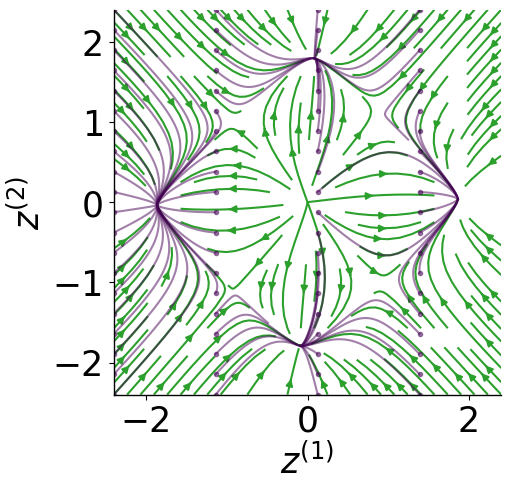

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))

ii = 0
ax.streamplot(x_, y_, u_, v_, color='#2ca02c')

for trial in range(0, 400, 5):
    plt.plot(data['latents'][trial, :1, 0], data['latents'][trial, :1, 1], color='#440154', marker='.', alpha=0.5)
    plt.plot(data['latents'][trial, :, 0], data['latents'][trial, :, 1], color='#440154', alpha=0.5)

ax.set_xlabel(r'$z^{(1)}$', fontsize=25)
ax.set_ylabel(r'$z^{(2)}$', fontsize=25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.tick_params(axis='both', which='major', labelsize=25)

### Figure 2B:

/tmp/ipykernel_782530/3298431304.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


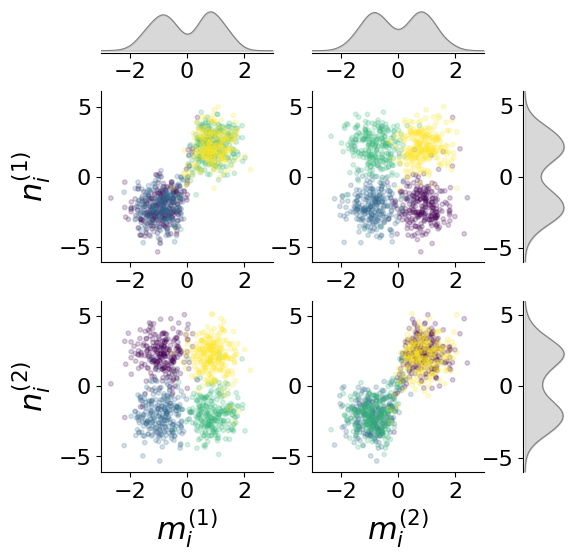

In [5]:
# Set random seed for reproducibility
np.random.seed(42)

# Create figure with custom layout
fig = plt.figure(figsize=(6, 6))
gs = GridSpec(3, 3, width_ratios=[4, 4, 1], height_ratios=[1, 4, 4], wspace=0.3, hspace=0.3)

# Histograms (top row)
ax_hist_x1 = fig.add_subplot(gs[0, 0])
ax_hist_x2 = fig.add_subplot(gs[0, 1])

# Histograms (right column)
ax_hist_y1 = fig.add_subplot(gs[1, 2])
ax_hist_y2 = fig.add_subplot(gs[2, 2])

# Scatter plots
ax_scatter_11 = fig.add_subplot(gs[1, 0])
ax_scatter_12 = fig.add_subplot(gs[1, 1])
ax_scatter_21 = fig.add_subplot(gs[2, 0])
ax_scatter_22 = fig.add_subplot(gs[2, 1])

M_hat = M_data[inv_perm, :]
N_hat = N_data[inv_perm, :]

# Scatter + centers
def scatter_with_centers(ax, data_1, data_2, c):
    ax.scatter(data_1, data_2, c=c, cmap='viridis', s=10, alpha=0.2)
    

# Plot scatter plots
final_labels = np.repeat([1, 2, 3, 4], 250)
scatter_with_centers(ax_scatter_11, M_hat[:,0], N_hat[:,0], c=final_labels)
scatter_with_centers(ax_scatter_12, M_hat[:,1], N_hat[:,0], c=final_labels)
scatter_with_centers(ax_scatter_21, M_hat[:,0], N_hat[:,1], c=final_labels)
scatter_with_centers(ax_scatter_22, M_hat[:,1], N_hat[:,1], c=final_labels)

def plot_kde(ax, data, vertical=False, color="gray"):
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min() - 1, data.max() + 1, 200)
    y_vals = kde(x_vals)

    if vertical:
        ax.plot(y_vals, x_vals, color=color, linewidth=0.8)
        ax.fill_betweenx(x_vals, 0, y_vals, color=color, alpha=0.3)
        ax.spines[['right','bottom', 'top']].set_visible(False)
        ax.set_yticks([-5, 0, 5])
        ax.tick_params(axis='y', labelsize=16)
        ax.set_ylim([-6, 6])
        ax.set_xticks([])
    else:
        ax.plot(x_vals, y_vals, color=color, linewidth=0.8)
        ax.fill_between(x_vals, 0, y_vals, color=color, alpha=0.3)
        ax.spines[['left','right','top']].set_visible(False)
        ax.set_xticks([-2, 0, 2])
        ax.tick_params(axis='x', labelsize=16)
        ax.set_xlim([-3, 3])
        ax.set_yticks([])

# Plot KDEs
plot_kde(ax_hist_x1, M_hat[:, 0])
plot_kde(ax_hist_x2, M_hat[:, 1])
plot_kde(ax_hist_y1, N_hat[:, 0], vertical=True)
plot_kde(ax_hist_y2, N_hat[:, 1], vertical=True)

for ax in [ax_scatter_11, ax_scatter_12, ax_scatter_21, ax_scatter_22]:
    ax.set_xlim([-3, 3])
    ax.set_ylim([-6.1, 6.1])
    ax.set_xticks([-2, 0, 2])
    ax.set_yticks([-5, 0, 5])
    ax.spines[['right','top']].set_visible(False)

ax_scatter_11.set_ylabel(r'$n_i^{(1)}$', fontsize=22)
ax_scatter_21.set_ylabel(r'$n_i^{(2)}$', fontsize=22)
ax_scatter_21.set_xlabel(r'$m_i^{(1)}$', fontsize=22)
ax_scatter_22.set_xlabel(r'$m_i^{(2)}$', fontsize=22)

ax_scatter_11.tick_params(axis='both', which='major', labelsize=16)
ax_scatter_12.tick_params(axis='both', which='major', labelsize=16)
ax_scatter_21.tick_params(axis='both', which='major', labelsize=16)
ax_scatter_22.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.show()

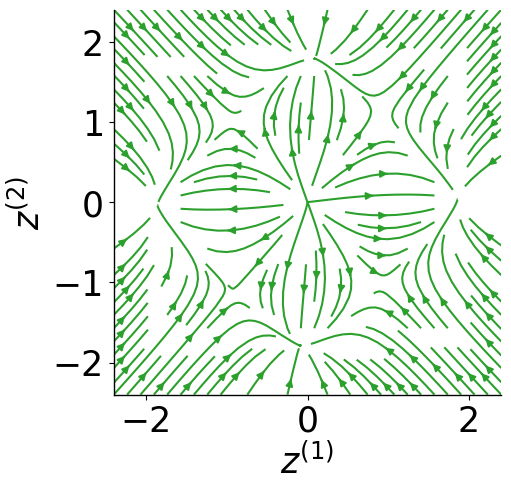

In [ ]:
resolution = 30
x_, y_ = np.meshgrid(
    np.linspace(-2.4, 2.4, num=resolution), 
    np.linspace(-2.4, 2.4, num=resolution)
)

u_ = np.zeros_like(x_)
v_ = np.zeros_like(y_)
u_left_ = np.zeros_like(x_)
v_left_ = np.zeros_like(y_)
u_right_ = np.zeros_like(x_)
v_right_ = np.zeros_like(y_)
energy = np.zeros_like(x_)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for i in range(resolution):
    for j in range(resolution):
        xy = np.array([x_[i, j], y_[i, j]])
        uv_s = -xy + (1/1000) * np.tanh( ( xy @ M_hat.T) ) @ N_hat
        u_[i, j] = uv_s[0]
        v_[i, j] = uv_s[1]

fig, ax = plt.subplots(figsize=(5, 5))

ii = 0
ax.streamplot(x_, y_, u_, v_, color='#2ca02c')

ax.set_xlabel(r'$z^{(1)}$', fontsize=25)
ax.set_ylabel(r'$z^{(2)}$', fontsize=25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.tick_params(axis='both', which='major', labelsize=25)

### Figure 2C:

/tmp/ipykernel_782530/1405796241.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


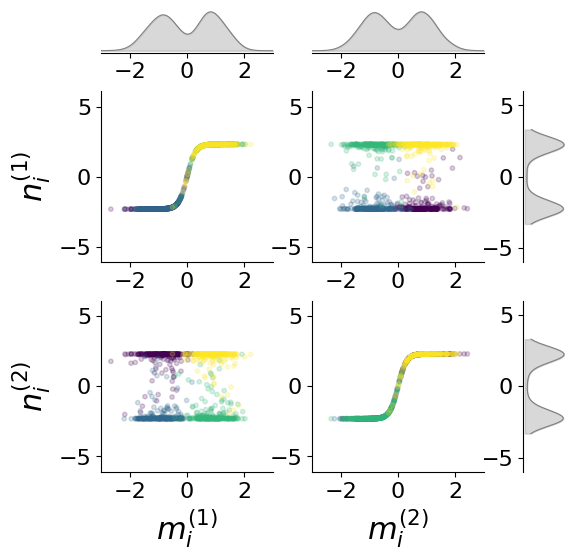

In [7]:
# Set random seed for reproducibility
np.random.seed(42)

# Create figure with custom layout
fig = plt.figure(figsize=(6, 6))
gs = GridSpec(3, 3, width_ratios=[4, 4, 1], height_ratios=[1, 4, 4], wspace=0.3, hspace=0.3)

# Histograms (top row)
ax_hist_x1 = fig.add_subplot(gs[0, 0])
ax_hist_x2 = fig.add_subplot(gs[0, 1])

# Histograms (right column)
ax_hist_y1 = fig.add_subplot(gs[1, 2])
ax_hist_y2 = fig.add_subplot(gs[2, 2])

# Scatter plots
ax_scatter_11 = fig.add_subplot(gs[1, 0])
ax_scatter_12 = fig.add_subplot(gs[1, 1])
ax_scatter_21 = fig.add_subplot(gs[2, 0])
ax_scatter_22 = fig.add_subplot(gs[2, 1])

M_hat = M_data[inv_perm, :]
N_hat = enms[inv_perm, :]

# Scatter + centers
def scatter_with_centers(ax, data_1, data_2, c):
    ax.scatter(data_1, data_2, c=c, cmap='viridis', s=10, alpha=0.2)
    

# Plot scatter plots
final_labels = np.repeat([1, 2, 3, 4], 250)
scatter_with_centers(ax_scatter_11, M_hat[:,0], N_hat[:,0], c=final_labels)
scatter_with_centers(ax_scatter_12, M_hat[:,1], N_hat[:,0], c=final_labels)
scatter_with_centers(ax_scatter_21, M_hat[:,0], N_hat[:,1], c=final_labels)
scatter_with_centers(ax_scatter_22, M_hat[:,1], N_hat[:,1], c=final_labels)

def plot_kde(ax, data, vertical=False, color="gray"):
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min() - 1, data.max() + 1, 200)
    y_vals = kde(x_vals)

    if vertical:
        ax.plot(y_vals, x_vals, color=color, linewidth=0.8)
        ax.fill_betweenx(x_vals, 0, y_vals, color=color, alpha=0.3)
        ax.spines[['right','bottom', 'top']].set_visible(False)
        ax.set_yticks([-5, 0, 5])
        ax.tick_params(axis='y', labelsize=16)
        ax.set_ylim([-6, 6])
        ax.set_xticks([])
    else:
        ax.plot(x_vals, y_vals, color=color, linewidth=0.8)
        ax.fill_between(x_vals, 0, y_vals, color=color, alpha=0.3)
        ax.spines[['left','right','top']].set_visible(False)
        ax.set_xticks([-2, 0, 2])
        ax.tick_params(axis='x', labelsize=16)
        ax.set_xlim([-3, 3])
        ax.set_yticks([])

# Plot KDEs
plot_kde(ax_hist_x1, M_hat[:, 0])
plot_kde(ax_hist_x2, M_hat[:, 1])
plot_kde(ax_hist_y1, N_hat[:, 0], vertical=True)
plot_kde(ax_hist_y2, N_hat[:, 1], vertical=True)

for ax in [ax_scatter_11, ax_scatter_12, ax_scatter_21, ax_scatter_22]:
    ax.set_xlim([-3, 3])
    ax.set_ylim([-6.1, 6.1])
    ax.set_xticks([-2, 0, 2])
    ax.set_yticks([-5, 0, 5])
    ax.spines[['right','top']].set_visible(False)

ax_scatter_11.set_ylabel(r'$n_i^{(1)}$', fontsize=22)
ax_scatter_21.set_ylabel(r'$n_i^{(2)}$', fontsize=22)
ax_scatter_21.set_xlabel(r'$m_i^{(1)}$', fontsize=22)
ax_scatter_22.set_xlabel(r'$m_i^{(2)}$', fontsize=22)

ax_scatter_11.tick_params(axis='both', which='major', labelsize=16)
ax_scatter_12.tick_params(axis='both', which='major', labelsize=16)
ax_scatter_21.tick_params(axis='both', which='major', labelsize=16)
ax_scatter_22.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.show()

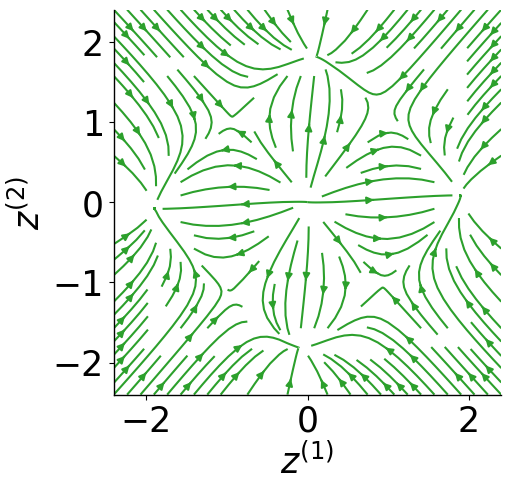

In [ ]:
resolution = 30
x_, y_ = np.meshgrid(
    np.linspace(-2.4, 2.4, num=resolution), 
    np.linspace(-2.4, 2.4, num=resolution)
)

u_ = np.zeros_like(x_)
v_ = np.zeros_like(y_)
u_left_ = np.zeros_like(x_)
v_left_ = np.zeros_like(y_)
u_right_ = np.zeros_like(x_)
v_right_ = np.zeros_like(y_)
energy = np.zeros_like(x_)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for i in range(resolution):
    for j in range(resolution):
        xy = np.array([x_[i, j], y_[i, j]])
        uv_s = -xy + (1/1000) * np.tanh( ( xy @ M_hat.T) ) @ N_hat
        u_[i, j] = uv_s[0]
        v_[i, j] = uv_s[1]

fig, ax = plt.subplots(figsize=(5, 5))

ii = 0
ax.streamplot(x_, y_, u_, v_, color='#2ca02c')

ax.set_xlabel(r'$z^{(1)}$', fontsize=25)
ax.set_ylabel(r'$z^{(2)}$', fontsize=25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.tick_params(axis='both', which='major', labelsize=25)

### Figure 2D:

In [9]:
# This code generates samples from a mixture of three Gaussian distributions, each with specified means, covariances, and weights. 
# The samples are then centered by subtracting the mean of the first 1000 samples. 
# This makes the mean of this distribution zero.
means = [np.array([-0.5, 1]), np.array([2, -5]), np.array([-1, -2.5])]
covs = [np.eye(2), np.eye(2), np.eye(2)]
weights = [0.3, 0.2, 0.5]

# Number of samples
n_samples = 1000

# Step 1: Choose which component each sample comes from
components = np.random.choice([0,1,2], size=n_samples, p=weights)

# Step 2: Sample from the chosen Gaussian
samples = np.array([np.random.multivariate_normal(means[i], 0.01*covs[i]) for i in components])
samples = samples[:1000, :] - np.mean(samples[:1000, :], axis=0)
np.mean(samples, axis=0)

array([-4.97824004e-16, -1.59872116e-16])

/tmp/ipykernel_782530/4274118200.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


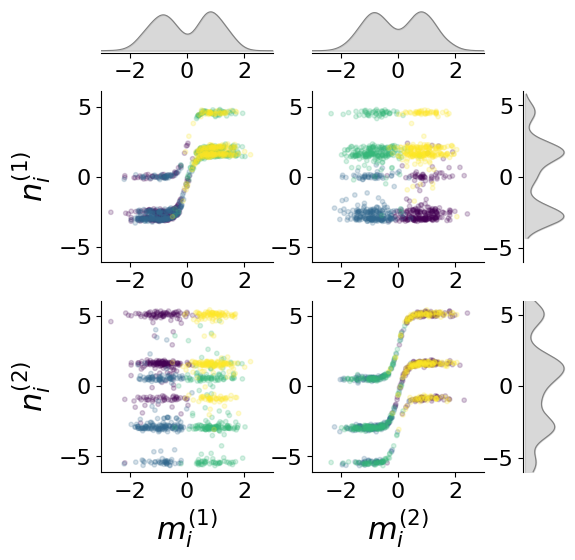

In [10]:
# Set random seed for reproducibility
np.random.seed(42)

# Create figure with custom layout
fig = plt.figure(figsize=(6, 6))
gs = GridSpec(3, 3, width_ratios=[4, 4, 1], height_ratios=[1, 4, 4], wspace=0.3, hspace=0.3)

# Histograms (top row)
ax_hist_x1 = fig.add_subplot(gs[0, 0])
ax_hist_x2 = fig.add_subplot(gs[0, 1])

# Histograms (right column)
ax_hist_y1 = fig.add_subplot(gs[1, 2])
ax_hist_y2 = fig.add_subplot(gs[2, 2])

# Scatter plots
ax_scatter_11 = fig.add_subplot(gs[1, 0])
ax_scatter_12 = fig.add_subplot(gs[1, 1])
ax_scatter_21 = fig.add_subplot(gs[2, 0])
ax_scatter_22 = fig.add_subplot(gs[2, 1])

M_hat = M_data[inv_perm, :]
N_hat = enms[inv_perm, :] + samples

# Scatter + centers
def scatter_with_centers(ax, data_1, data_2, c):
    ax.scatter(data_1, data_2, c=c, cmap='viridis', s=10, alpha=0.2)
    

# Plot scatter plots
final_labels = np.repeat([1, 2, 3, 4], 250)
scatter_with_centers(ax_scatter_11, M_hat[:,0], N_hat[:,0], c=final_labels)
scatter_with_centers(ax_scatter_12, M_hat[:,1], N_hat[:,0], c=final_labels)
scatter_with_centers(ax_scatter_21, M_hat[:,0], N_hat[:,1], c=final_labels)
scatter_with_centers(ax_scatter_22, M_hat[:,1], N_hat[:,1], c=final_labels)

def plot_kde(ax, data, vertical=False, color="gray"):
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min() - 1, data.max() + 1, 200)
    y_vals = kde(x_vals)

    if vertical:
        ax.plot(y_vals, x_vals, color=color, linewidth=0.8)
        ax.fill_betweenx(x_vals, 0, y_vals, color=color, alpha=0.3)
        ax.spines[['right','bottom', 'top']].set_visible(False)
        ax.set_yticks([-5, 0, 5])
        ax.tick_params(axis='y', labelsize=16)
        ax.set_ylim([-6, 6])
        ax.set_xticks([])
    else:
        ax.plot(x_vals, y_vals, color=color, linewidth=0.8)
        ax.fill_between(x_vals, 0, y_vals, color=color, alpha=0.3)
        ax.spines[['left','right','top']].set_visible(False)
        ax.set_xticks([-2, 0, 2])
        ax.tick_params(axis='x', labelsize=16)
        ax.set_xlim([-3, 3])
        ax.set_yticks([])

# Plot KDEs
plot_kde(ax_hist_x1, M_hat[:, 0])
plot_kde(ax_hist_x2, M_hat[:, 1])
plot_kde(ax_hist_y1, N_hat[:, 0], vertical=True)
plot_kde(ax_hist_y2, N_hat[:, 1], vertical=True)

for ax in [ax_scatter_11, ax_scatter_12, ax_scatter_21, ax_scatter_22]:
    ax.set_xlim([-3, 3])
    ax.set_ylim([-6.1, 6.1])
    ax.set_xticks([-2, 0, 2])
    ax.set_yticks([-5, 0, 5])
    ax.spines[['right','top']].set_visible(False)

ax_scatter_11.set_ylabel(r'$n_i^{(1)}$', fontsize=22)
ax_scatter_21.set_ylabel(r'$n_i^{(2)}$', fontsize=22)
ax_scatter_21.set_xlabel(r'$m_i^{(1)}$', fontsize=22)
ax_scatter_22.set_xlabel(r'$m_i^{(2)}$', fontsize=22)

ax_scatter_11.tick_params(axis='both', which='major', labelsize=16)
ax_scatter_12.tick_params(axis='both', which='major', labelsize=16)
ax_scatter_21.tick_params(axis='both', which='major', labelsize=16)
ax_scatter_22.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.show()

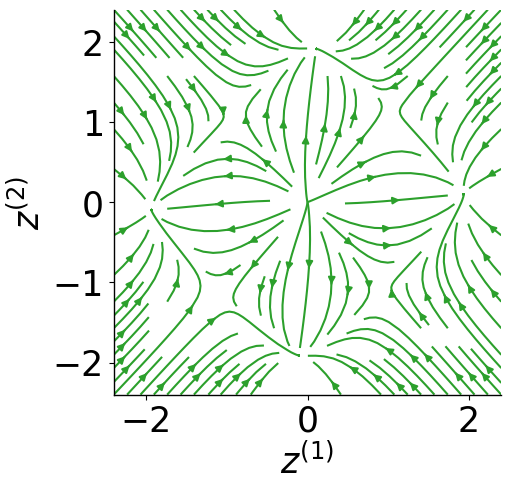

In [ ]:
resolution = 30
x_, y_ = np.meshgrid(
    np.linspace(-2.4, 2.4, num=resolution), 
    np.linspace(-2.4, 2.4, num=resolution)
)

u_ = np.zeros_like(x_)
v_ = np.zeros_like(y_)
u_left_ = np.zeros_like(x_)
v_left_ = np.zeros_like(y_)
u_right_ = np.zeros_like(x_)
v_right_ = np.zeros_like(y_)
energy = np.zeros_like(x_)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for i in range(resolution):
    for j in range(resolution):
        xy = np.array([x_[i, j], y_[i, j]])
        uv_s = -xy + (1/1000) * np.tanh( ( xy @ M_hat.T) ) @ N_hat
        u_[i, j] = uv_s[0]
        v_[i, j] = uv_s[1]

fig, ax = plt.subplots(figsize=(5, 5))

ii = 0
ax.streamplot(x_, y_, u_, v_, color='#2ca02c')


ax.set_xlabel(r'$z^{(1)}$', fontsize=25)
ax.set_ylabel(r'$z^{(2)}$', fontsize=25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.tick_params(axis='both', which='major', labelsize=25)

### Figure 2E:

##### i) Train LINT

In [ ]:
from __future__ import print_function
import matplotlib.pyplot as plt
import argparse

# Bring your packages onto the path
import sys, os
sys.path.append(os.path.abspath('..'))

import train
import utilities

args_list = [
    '--k', '1',
    '--n_splits', '5',
    '--latent_dim', '2',
    '--hidden_dim', '1000',
    '--obs_dim', '1000',
    '--batch_size', '10',
    '--seed', '1',
    '--lr', '0.001',
    '--accel',
    '--weight_decay', '1e-4',
    '--activation', 'tanh',
    '--standard_training_epochs', '1000',
    '--regularizer', '1e-5',
    '--alpha', '0.1',
    '--datapath', os.path.abspath('../data/quadstable_attractors.npz'),
    '--modelpath', os.path.abspath('../lint/quadstable_attractors'),
]

# Default parameters
parser = argparse.ArgumentParser(
    description='RNN, mean-field dynamics, normalizing flows, neural dynamics inference'
)
parser.add_argument(
    '--k', type=int, default=1,
    help='index of the current fold (default: 1)'
)
parser.add_argument(
    '--n_splits', type=int, default=5,
    help='number of splits for KFold cross-validation (default: 5)'
)
parser.add_argument(
    '--latent_dim', type=int, default=2,
    help='dimensionality of the latent space (default: 2)'
)
parser.add_argument(
    '--hidden_dim', type=int, default=500,
    help='dimensionality of the hidden layer (default: 500)'
)
parser.add_argument(
    '--obs_dim', type=int, default=-1,
    help='dimensionality of the observation space (default: -1)'
)
parser.add_argument(
    '--batch_size', type=int, default=25,
    help='input batch size for training (default: 25)'
)
parser.add_argument(
    '--accel', action='store_true', 
    help='use accelerator'
)
parser.add_argument(
    '--seed', type=int, default=1,
    help='random seed (default: 1)'
)
parser.add_argument(
    '--lr', type=float, default=1e-4,
    help='learning rate (default: 1e-4)'
)
parser.add_argument(
    '--weight_decay', type=float, default=1e-5,
    help='weight decay (default: 1e-5)'
)
parser.add_argument(
    '--activation', type=str, default='tanh',
    choices=['tanh', 'relu', 'softplus', 'sigmoid'],
    help='activation function (default: tanh)'
)
parser.add_argument(
    '--scale', type=float, default=1.0,
    help='scale factor for the input (default: 1.0)'
)
parser.add_argument(
    '--bias', action='store_true',
    help='include bias term (default: False)'
)
parser.add_argument(
    '--standard_training_epochs', type=int, default=1000, # 1000 for quad, 1000 for others
    help='number of standard training epochs (default: 1000)'
)
parser.add_argument(
    '--mbd_training_epochs', type=int, default=100,
    help='number of epochs for mbd training (default: 100)'
)
parser.add_argument(
    '--n_training_epochs', type=int, default=100,
    help='number of epochs for n training (default: 100)'
)
parser.add_argument(
    '--regularizer', type=float, default=1.0,
    help='regularization strength (default: 1.0)'
)
parser.add_argument(
    '--nsamples', type=int, default=500,
    help='number of samples or "neurons" used for inference (default: 500)'
)
parser.add_argument(
    '--datapath', type=str, default='../data/quadstable_attractors.npz',
    help='path to the data file'
)
parser.add_argument(
    '--modelpath', type=str, default='../lint/quadstable_attractors',
    help='path to the model file'
)
parser.add_argument(
    '--alpha', type=float, default=1.0,
    help='alpha parameter (default: 1.0)'
)
parser.add_argument(
    '--train_id', type=int, default=0,
    help='ID of the training run (default: 0)'
)

args = parser.parse_args(args_list)

In [13]:
model, train_losses, valid_losses, test_losses = train.train_lint(args)

Using device: cuda
| epoch      1 | train loss 56.01270 | val loss  7.00346 | test loss  6.95803  (x 1000)
| epoch      2 | train loss 55.99630 | val loss  7.00190 | test loss  6.95654  (x 1000)
| epoch      3 | train loss 55.98666 | val loss  7.00087 | test loss  6.95549  (x 1000)
| epoch      4 | train loss 55.97809 | val loss  6.99975 | test loss  6.95434  (x 1000)
| epoch      5 | train loss 55.96715 | val loss  6.99827 | test loss  6.95272  (x 1000)
| epoch      6 | train loss 55.95207 | val loss  6.99617 | test loss  6.95049  (x 1000)
| epoch      7 | train loss 55.93148 | val loss  6.99340 | test loss  6.94753  (x 1000)
| epoch      8 | train loss 55.90405 | val loss  6.98964 | test loss  6.94354  (x 1000)
| epoch      9 | train loss 55.86754 | val loss  6.98471 | test loss  6.93834  (x 1000)
| epoch     10 | train loss 55.81958 | val loss  6.97812 | test loss  6.93138  (x 1000)
| epoch     11 | train loss 55.75517 | val loss  6.96903 | test loss  6.92179  (x 1000)
| epoch     1

##### ii) Load LINT parameters

In [ ]:
params = torch.load(f"../lint/quadstable_attractors/model_fold_1_seed_1_id_0.pth")

In [14]:
from torch.nn import functional as F

model = train.ValenteRNN(
    latent_dim=params['args']['latent_dim'],
    hidden_dim=params['args']['obs_dim'],
    externalinput_dim=0,
    activation=F.tanh,
    alpha=params['args']['alpha'],
    bias=params['args']['bias']
)

model.load_state_dict(params['model_state_dict'])
model.eval()

ValenteRNN(
  (linear1): Linear(in_features=2, out_features=1000, bias=False)
  (linear2): Linear(in_features=1000, out_features=2, bias=False)
)

In [15]:
M_lint = model.linear1.weight.cpu().detach().numpy()
N_lint = model.linear2.weight.cpu().detach().numpy().T

In [16]:
import utilities

k = 1
train_indices, valid_indices, test_indices = utilities.split_data(data['potentials'], params['args']['n_splits'], params['args']['seed'])
latents = data['potentials'][train_indices[k-1],:,:params['args']['obs_dim']] @ np.linalg.pinv(M_lint.T)
latents_ = np.reshape(latents, (-1, 2))
latents_ = np.insert(latents_, 0, 1.0, axis=1)
CT_pca_b = np.linalg.pinv(latents_.T @ latents_) @ latents_.T @ np.reshape(data['latents'][train_indices[k-1],:,:], (-1, 2))
CT_pca = CT_pca_b[1:, :]
C_pca_inv = np.linalg.pinv(CT_pca.T)
b_pca = CT_pca_b[0, :]
latents_hat = latents @ CT_pca + b_pca
test_latents_hat = (data['potentials'][test_indices[k-1],:,:params['args']['obs_dim']]) @ np.linalg.pinv(M_lint.T) @ CT_pca + b_pca
mse_vm_lint = np.mean((test_latents_hat - data['latents'][test_indices[k-1],:,:])**2)
print(f"VM Lint MSE: {mse_vm_lint}")

VM Lint MSE: 7.894358518154249e-31


##### iii) Plot

In [17]:
from sklearn.cluster import KMeans

M_lint_ = M_lint @ C_pca_inv
N_lint_ = N_lint @ CT_pca

k_opt = 4
X = np.hstack([M_lint_, N_lint_])
final_kmeans = KMeans(n_clusters=k_opt, random_state=42)
final_labels_lint = final_kmeans.fit_predict(X)

/tmp/ipykernel_782530/423305388.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


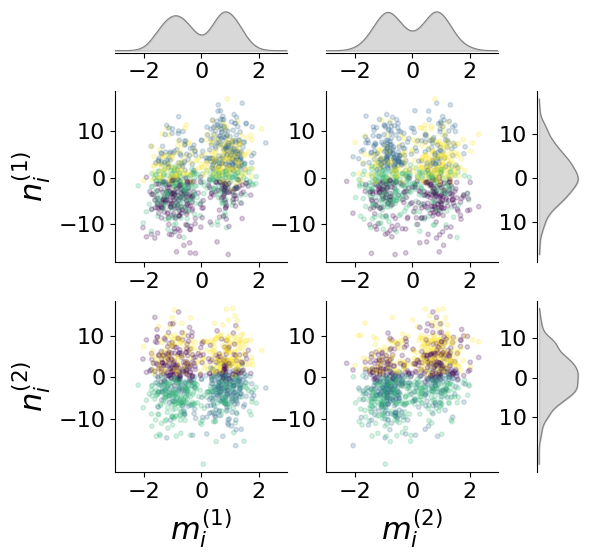

In [18]:
# Set random seed for reproducibility
np.random.seed(42)

# Create figure with custom layout
fig = plt.figure(figsize=(6, 6))
gs = GridSpec(3, 3, width_ratios=[4, 4, 1], height_ratios=[1, 4, 4], wspace=0.3, hspace=0.3)

# Histograms (top row)
ax_hist_x1 = fig.add_subplot(gs[0, 0])
ax_hist_x2 = fig.add_subplot(gs[0, 1])

# Histograms (right column)
ax_hist_y1 = fig.add_subplot(gs[1, 2])
ax_hist_y2 = fig.add_subplot(gs[2, 2])

# Scatter plots
ax_scatter_11 = fig.add_subplot(gs[1, 0])
ax_scatter_12 = fig.add_subplot(gs[1, 1])
ax_scatter_21 = fig.add_subplot(gs[2, 0])
ax_scatter_22 = fig.add_subplot(gs[2, 1])

M_hat = M_lint_
N_hat = N_lint_

# Scatter + centers
def scatter_with_centers(ax, data_1, data_2, c):
    ax.scatter(data_1, data_2, c=c, cmap='viridis', s=10, alpha=0.2)
    

# Plot scatter plots
scatter_with_centers(ax_scatter_11, M_hat[:,0], N_hat[:,0], c=final_labels_lint)
scatter_with_centers(ax_scatter_12, M_hat[:,1], N_hat[:,0], c=final_labels_lint)
scatter_with_centers(ax_scatter_21, M_hat[:,0], N_hat[:,1], c=final_labels_lint)
scatter_with_centers(ax_scatter_22, M_hat[:,1], N_hat[:,1], c=final_labels_lint)

def plot_kde(ax, data, vertical=False, color="gray"):
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min() - 1, data.max() + 1, 200)
    y_vals = kde(x_vals)

    if vertical:
        ax.plot(y_vals, x_vals, color=color, linewidth=0.8)
        ax.fill_betweenx(x_vals, 0, y_vals, color=color, alpha=0.3)
        ax.spines[['right','bottom', 'top']].set_visible(False)
        ax.set_yticks([-10, 0, 10])
        ax.tick_params(axis='y', labelsize=16)
        ax.set_xticks([])
    else:
        ax.plot(x_vals, y_vals, color=color, linewidth=0.8)
        ax.fill_between(x_vals, 0, y_vals, color=color, alpha=0.3)
        ax.spines[['left','right','top']].set_visible(False)
        ax.set_xticks([-2, 0, 2])
        ax.tick_params(axis='x', labelsize=16)
        ax.set_xlim([-3, 3])
        ax.set_yticks([])

# Plot KDEs
plot_kde(ax_hist_x1, M_hat[:, 0])
plot_kde(ax_hist_x2, M_hat[:, 1])
plot_kde(ax_hist_y1, N_hat[:, 0], vertical=True)
plot_kde(ax_hist_y2, N_hat[:, 1], vertical=True)

for ax in [ax_scatter_11, ax_scatter_12, ax_scatter_21, ax_scatter_22]:
    ax.set_xlim([-3, 3])
    ax.set_xticks([-2, 0, 2])
    ax.set_yticks([-10, 0, 10])
    ax.spines[['right','top']].set_visible(False)

ax_scatter_11.set_ylabel(r'$n_i^{(1)}$', fontsize=22)
ax_scatter_21.set_ylabel(r'$n_i^{(2)}$', fontsize=22)
ax_scatter_21.set_xlabel(r'$m_i^{(1)}$', fontsize=22)
ax_scatter_22.set_xlabel(r'$m_i^{(2)}$', fontsize=22)

ax_scatter_11.tick_params(axis='both', which='major', labelsize=16)
ax_scatter_12.tick_params(axis='both', which='major', labelsize=16)
ax_scatter_21.tick_params(axis='both', which='major', labelsize=16)
ax_scatter_22.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.show()

In [ ]:
np.savez(
    '../data/lint/quadstable_attractors.npz',
    latents = latents_hat,
    MBD = M_hat,
    potentials = latents_hat @ M_hat.T,
    rates = np.tanh(latents_hat @ M_hat.T)
)

### Figure 2F:

##### i) Train Connector

In [ ]:
args_list = [
    '--k', '1',
    '--n_splits', '5',
    '--latent_dim', '2',
    '--hidden_dim', '128',
    '--obs_dim', '1000',
    '--batch_size', '64',
    '--seed', '1',
    '--lr', '0.001',
    '--accel',
    '--weight_decay', '1e-5',
    '--activation', 'tanh',
    '--mbd_training_epochs', '1000',
    '--n_training_epochs', '1000',
    '--regularizer', '1e-4',
    '--nsamples', '1000',
    '--scale', '1.0',
    '--alpha', '0.1',
    '--datapath', os.path.abspath('../data/lint/quadstable_attractors.npz'),
    '--modelpath', os.path.abspath('../lint/quadstable_attractors/connector'),
]

# Default parameters
parser = argparse.ArgumentParser(
    description='RNN, mean-field dynamics, normalizing flows, neural dynamics inference'
)
parser.add_argument(
    '--k', type=int, default=1,
    help='index of the current fold (default: 1)'
)
parser.add_argument(
    '--n_splits', type=int, default=5,
    help='number of splits for KFold cross-validation (default: 5)'
)
parser.add_argument(
    '--latent_dim', type=int, default=2,
    help='dimensionality of the latent space (default: 2)'
)
parser.add_argument(
    '--hidden_dim', type=int, default=500,
    help='dimensionality of the hidden layer (default: 500)'
)
parser.add_argument(
    '--obs_dim', type=int, default=-1,
    help='dimensionality of the observation space (default: -1)'
)
parser.add_argument(
    '--batch_size', type=int, default=25,
    help='input batch size for training (default: 25)'
)
parser.add_argument(
    '--accel', action='store_true', 
    help='use accelerator'
)
parser.add_argument(
    '--seed', type=int, default=1,
    help='random seed (default: 1)'
)
parser.add_argument(
    '--lr', type=float, default=1e-4,
    help='learning rate (default: 1e-4)'
)
parser.add_argument(
    '--weight_decay', type=float, default=1e-5,
    help='weight decay (default: 1e-5)'
)
parser.add_argument(
    '--activation', type=str, default='tanh',
    choices=['tanh', 'relu', 'softplus', 'sigmoid'],
    help='activation function (default: tanh)'
)
parser.add_argument(
    '--scale', type=float, default=1.0,
    help='scale factor for the input (default: 1.0)'
)
parser.add_argument(
    '--bias', action='store_true',
    help='include bias term (default: False)'
)
parser.add_argument(
    '--standard_training_epochs', type=int, default=1000, # 1000 for quad, 1000 for others
    help='number of standard training epochs (default: 1000)'
)
parser.add_argument(
    '--mbd_training_epochs', type=int, default=100,
    help='number of epochs for mbd training (default: 100)'
)
parser.add_argument(
    '--n_training_epochs', type=int, default=100,
    help='number of epochs for n training (default: 100)'
)
parser.add_argument(
    '--regularizer', type=float, default=1.0,
    help='regularization strength (default: 1.0)'
)
parser.add_argument(
    '--nsamples', type=int, default=500,
    help='number of samples or "neurons" used for inference (default: 500)'
)
parser.add_argument(
    '--datapath', type=str, default='../data/lint/quadstable_attractors.npz',
    help='path to the data file'
)
parser.add_argument(
    '--modelpath', type=str, default='../lint/quadstable_attractors/connector',
    help='path to the model file'
)
parser.add_argument(
    '--alpha', type=float, default=1.0,
    help='alpha parameter (default: 1.0)'
)
parser.add_argument(
    '--train_id', type=int, default=0,
    help='ID of the training run (default: 0)'
)

args = parser.parse_args(args_list)

In [25]:
model, train_mbd_losses, train_n_losses, valid_n_losses, test_n_losses = train.train(args)

Using device: cuda
Inferring connectivity distribution over m, b, d...
| iter    100 | loss  1.54346
| iter    200 | loss  1.52646
| iter    300 | loss  1.56805
| iter    400 | loss  1.59675
| iter    500 | loss  1.50260
| iter    600 | loss  1.52268
| iter    700 | loss  1.54730
| iter    800 | loss  1.41709
| iter    900 | loss  1.45239
| iter   1000 | loss  1.51762
Inferring connectivity distribution over n given m, b, d...
| iter    100 | loss  0.00619
| iter    200 | loss  0.00335
| iter    300 | loss  0.00219
| iter    400 | loss  0.00199
| iter    500 | loss  0.00142
| iter    600 | loss  0.00224
| iter    700 | loss  0.00193
| iter    800 | loss  0.00127
| iter    900 | loss  0.00131
| iter   1000 | loss  0.00147
Training complete.


##### ii) Load Connector parameters

In [ ]:
params = torch.load(f"../lint/quadstable_attractors/connector/model_fold_1_seed_1_id_0.pth")

In [22]:
model = train.ConnectivityDistribution(
    mbd_dim=2,
    n_dim=2,
    time_dim=1,
    hidden_dim=params['args']['hidden_dim'],
    scale=params['args']['scale']
).to('cuda')

model.load_state_dict(params['model_state_dict'])

<All keys matched successfully>

In [23]:
Mb_model, N_model = model.sample(1000, sigma=1.0)
M_connector = Mb_model[:,:params['args']['latent_dim']].detach().cpu().numpy()
N_connector = N_model.detach().cpu().numpy()

##### iii) Plot

In [24]:
k_opt = 4
X = np.hstack([M_connector, N_connector])
final_kmeans = KMeans(n_clusters=k_opt, random_state=42)
final_labels_connector = final_kmeans.fit_predict(X)

/tmp/ipykernel_782530/3655489747.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


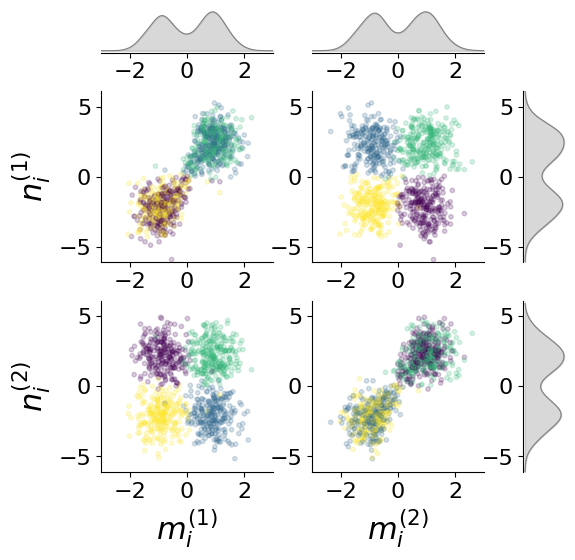

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde

# Set random seed for reproducibility
np.random.seed(42)

# Create figure with custom layout
fig = plt.figure(figsize=(6, 6))
gs = GridSpec(3, 3, width_ratios=[4, 4, 1], height_ratios=[1, 4, 4], wspace=0.3, hspace=0.3)

# Histograms (top row)
ax_hist_x1 = fig.add_subplot(gs[0, 0])
ax_hist_x2 = fig.add_subplot(gs[0, 1])

# Histograms (right column)
ax_hist_y1 = fig.add_subplot(gs[1, 2])
ax_hist_y2 = fig.add_subplot(gs[2, 2])

# Scatter plots
ax_scatter_11 = fig.add_subplot(gs[1, 0])
ax_scatter_12 = fig.add_subplot(gs[1, 1])
ax_scatter_21 = fig.add_subplot(gs[2, 0])
ax_scatter_22 = fig.add_subplot(gs[2, 1])

# Scatter + centers
def scatter_with_centers(ax, data_1, data_2, c):
    ax.scatter(data_1, data_2, c=c, cmap='viridis', s=10, alpha=0.2)

M_hat = M_connector
N_hat = N_connector


# Plot scatter plots
scatter_with_centers(ax_scatter_11, M_hat[:,0], N_hat[:,0], c=final_labels_connector)
scatter_with_centers(ax_scatter_12, M_hat[:,1], N_hat[:,0], c=final_labels_connector)
scatter_with_centers(ax_scatter_21, M_hat[:,0], N_hat[:,1], c=final_labels_connector)
scatter_with_centers(ax_scatter_22, M_hat[:,1], N_hat[:,1], c=final_labels_connector)

def plot_kde(ax, data, vertical=False, color="gray"):
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min() - 1, data.max() + 1, 200)
    y_vals = kde(x_vals)

    if vertical:
        ax.plot(y_vals, x_vals, color=color, linewidth=0.8)
        ax.fill_betweenx(x_vals, 0, y_vals, color=color, alpha=0.3)
        ax.spines[['right','bottom', 'top']].set_visible(False)
        ax.set_yticks([-5, 0, 5])
        ax.tick_params(axis='y', labelsize=16)
        ax.set_ylim([-6.1, 6.1])
        ax.set_xticks([])
    else:
        ax.plot(x_vals, y_vals, color=color, linewidth=0.8)
        ax.fill_between(x_vals, 0, y_vals, color=color, alpha=0.3)
        ax.spines[['left','right','top']].set_visible(False)
        ax.set_xticks([-2, 0, 2])
        ax.tick_params(axis='x', labelsize=16)
        ax.set_xlim([-3, 3])
        ax.set_yticks([])

# Plot KDEs
plot_kde(ax_hist_x1, M_hat[:, 0])
plot_kde(ax_hist_x2, M_hat[:, 1])
plot_kde(ax_hist_y1, N_hat[:, 0], vertical=True)
plot_kde(ax_hist_y2, N_hat[:, 1], vertical=True)

for ax in [ax_scatter_11, ax_scatter_12, ax_scatter_21, ax_scatter_22]:
    ax.set_xlim([-3, 3])
    ax.set_ylim([-6.1, 6.1])
    ax.set_xticks([-2, 0, 2])
    ax.set_yticks([-5, 0, 5])
    ax.spines[['right','top']].set_visible(False)
    #ax.set_facecolor("#440154")

ax_scatter_11.set_ylabel(r'$n_i^{(1)}$', fontsize=22)
ax_scatter_21.set_ylabel(r'$n_i^{(2)}$', fontsize=22)
ax_scatter_21.set_xlabel(r'$m_i^{(1)}$', fontsize=22)
ax_scatter_22.set_xlabel(r'$m_i^{(2)}$', fontsize=22)

ax_scatter_11.tick_params(axis='both', which='major', labelsize=16)
ax_scatter_12.tick_params(axis='both', which='major', labelsize=16)
ax_scatter_21.tick_params(axis='both', which='major', labelsize=16)
ax_scatter_22.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.show()

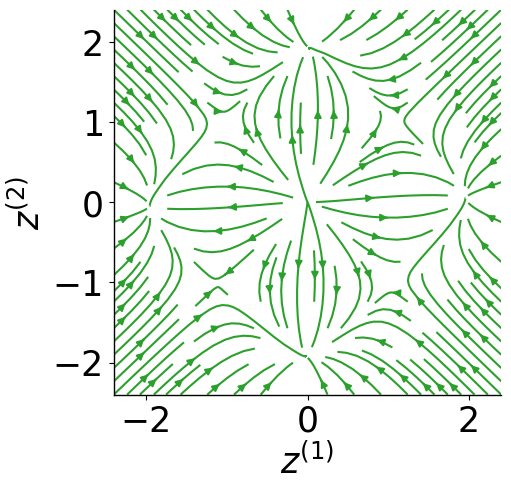

In [ ]:
resolution = 30
x_, y_ = np.meshgrid(
    np.linspace(-2.4, 2.4, num=resolution), 
    np.linspace(-2.4, 2.4, num=resolution)
)

u_ = np.zeros_like(x_)
v_ = np.zeros_like(y_)
u_left_ = np.zeros_like(x_)
v_left_ = np.zeros_like(y_)
u_right_ = np.zeros_like(x_)
v_right_ = np.zeros_like(y_)
energy = np.zeros_like(x_)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for i in range(resolution):
    for j in range(resolution):
        xy = np.array([x_[i, j], y_[i, j]])
        uv_s = -xy + (1/1000) * np.tanh( ( xy @ M_hat.T) ) @ N_hat
        u_[i, j] = uv_s[0]
        v_[i, j] = uv_s[1]

fig, ax = plt.subplots(figsize=(5, 5))

ii = 0
ax.streamplot(x_, y_, u_, v_, color='#2ca02c')

ax.set_xlabel(r'$z^{(1)}$', fontsize=25)
ax.set_ylabel(r'$z^{(2)}$', fontsize=25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.tick_params(axis='both', which='major', labelsize=25)

### Figure 2G:

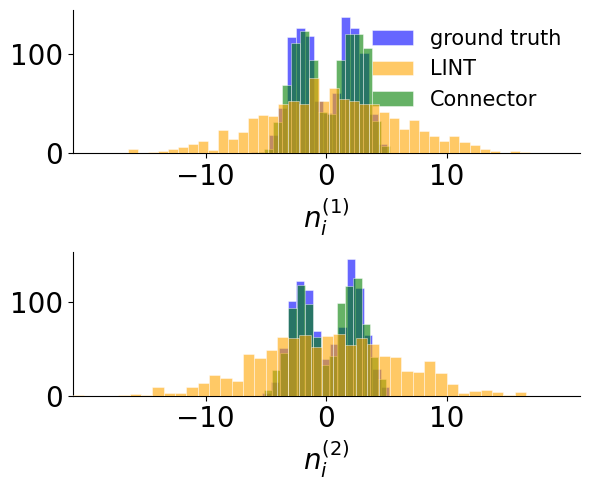

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5))

# First subplot - column 0
ax1.hist(N_data[:,0], bins=15, alpha=0.6, label=r'ground truth', 
        color='blue', edgecolor='white', linewidth=0.5, zorder=1000)
ax1.hist(N_lint_[:,0], bins=40, alpha=0.6, label=r'LINT', 
        color='orange', edgecolor='white', linewidth=0.5, zorder=1200)
ax1.hist(N_connector[:,0], bins=15, alpha=0.6, label=r'Connector', 
        color='green', edgecolor='white', linewidth=0.5, zorder=1100)

ax1.legend(fontsize=15, loc='upper right', frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlabel(r'$n_i^{(1)}$', fontsize=20)
ax1.set_xlim([-21, 21])
ax1.set_xticks([-10, 0, 10])
ax1.tick_params(labelsize=20)

# Second subplot - column 1
ax2.hist(N_data[:,1], bins=15, alpha=0.6, label=r'ground truth', 
        color='blue', edgecolor='white', linewidth=0.5, zorder=1000)
ax2.hist(N_lint_[:,1], bins=40, alpha=0.6, label=r'LINT', 
        color='orange', edgecolor='white', linewidth=0.5, zorder=1200)
ax2.hist(N_connector[:,1], bins=15, alpha=0.6, label=r'Connector', 
        color='green', edgecolor='white', linewidth=0.5, zorder=1100)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xlabel(r'$n_i^{(2)}$', fontsize=20)
ax2.set_xlim([-21, 21])
ax2.set_xticks([-10, 0, 10])
ax2.tick_params(labelsize=20)

plt.tight_layout()
plt.show()

### Figure 2H:

In [28]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import KFold

X = np.hstack([M_data, N_data])

# Test multiple values of k
k_values = range(1, 10)
llk_data = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for k in range(1, 10):
    fold_llks = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]

        model = GaussianMixture(n_components=k, random_state=42)
        model.fit(X_train)

        # model.score returns average log-likelihood per sample
        fold_llks.append(model.score(X_test))

    # Average over folds
    llk_data.append(fold_llks)

X = np.hstack([M_lint_, N_lint_])

# Test multiple values of k
k_values = range(1, 10)
llk_lint = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for k in range(1, 10):
    fold_llks = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]

        model = GaussianMixture(n_components=k, random_state=42)
        model.fit(X_train)

        # model.score returns average log-likelihood per sample
        fold_llks.append(model.score(X_test))

    # Average over folds
    llk_lint.append(fold_llks)

X = np.hstack([M_connector, N_connector])

# Test multiple values of k
k_values = range(1, 10)
llk_connector = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for k in range(1, 10):
    fold_llks = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]

        model = GaussianMixture(n_components=k, random_state=42)
        model.fit(X_train)

        # model.score returns average log-likelihood per sample
        fold_llks.append(model.score(X_test))

    # Average over folds
    llk_connector.append(fold_llks)

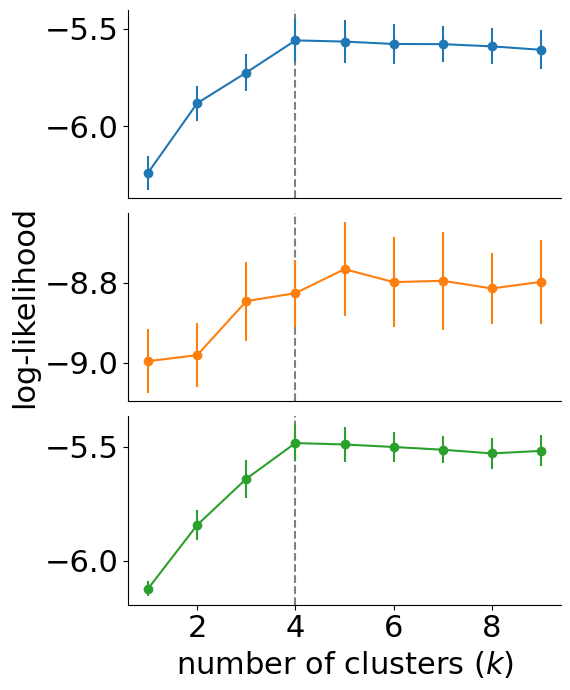

In [29]:
# Example data
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 7))

llk_data_ = np.array(llk_data)
# Primary y-axis (ours + ground truth)
ax1.axvline(x=4, color='gray', linestyle='--')
ax1.errorbar(range(1, 10), np.mean(llk_data_, axis=1), yerr=np.std(llk_data_, axis=1), fmt='o-', label='ground truth', c="C0")

ax1.tick_params(axis='y', labelsize=22)
ax1.tick_params(axis='x', labelsize=22)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xticks([])

llk_lint_ = np.array(llk_lint)
# Primary y-axis (ours + ground truth)
ax2.axvline(x=4, color='gray', linestyle='--')
ax2.errorbar(range(1, 10), np.mean(llk_lint_, axis=1), yerr=np.std(llk_lint_, axis=1), fmt='o-', label='LINT', c="C1")

ax2.set_ylabel('log-likelihood', fontsize=22)
ax2.tick_params(axis='y', labelsize=22)
ax2.tick_params(axis='x', labelsize=22)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xticks([])

llk_connector_ = np.array(llk_connector)
# Primary y-axis (ours + ground truth)
ax3.axvline(x=4, color='gray', linestyle='--')
ax3.errorbar(range(1, 10), np.mean(llk_connector_, axis=1), yerr=np.std(llk_connector_, axis=1), fmt='o-', label='Connector', c="C2")

ax3.set_xlabel(r'number of clusters ($k$)', fontsize=22)
ax3.tick_params(axis='y', labelsize=22)
ax3.tick_params(axis='x', labelsize=22)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.set_xticks([2, 4, 6, 8])

fig.tight_layout()

# Generate Figure 3

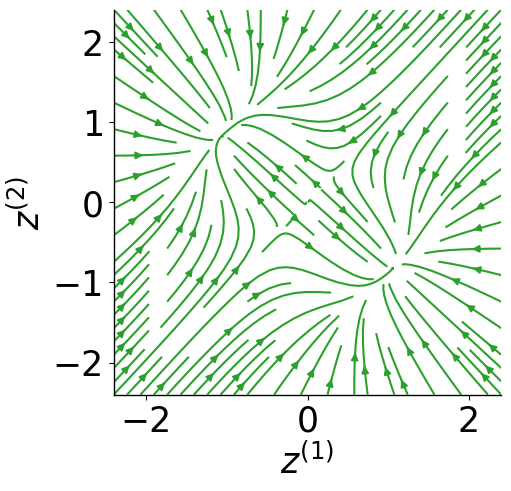

In [ ]:
resolution = 30
x_, y_ = np.meshgrid(
    np.linspace(-2.4, 2.4, num=resolution), 
    np.linspace(-2.4, 2.4, num=resolution)
)

M_hat = np.copy(M_data[inv_perm,:])
N_hat = np.copy(N_data[inv_perm,:])
M_hat[750:,:] = 0

u_ = np.zeros_like(x_)
v_ = np.zeros_like(y_)
u_left_ = np.zeros_like(x_)
v_left_ = np.zeros_like(y_)
u_right_ = np.zeros_like(x_)
v_right_ = np.zeros_like(y_)
energy = np.zeros_like(x_)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for i in range(resolution):
    for j in range(resolution):
        xy = np.array([x_[i, j], y_[i, j]])
        uv_s = -xy + (1/1000) * np.tanh( ( xy @ M_hat.T) ) @ N_hat
        u_[i, j] = uv_s[0]
        v_[i, j] = uv_s[1]

fig, ax = plt.subplots(figsize=(5, 5))

ii = 0
ax.streamplot(x_, y_, u_, v_, color='#2ca02c')

ax.set_xlabel(r'$z^{(1)}$', fontsize=25)
ax.set_ylabel(r'$z^{(2)}$', fontsize=25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.tick_params(axis='both', which='major', labelsize=25)

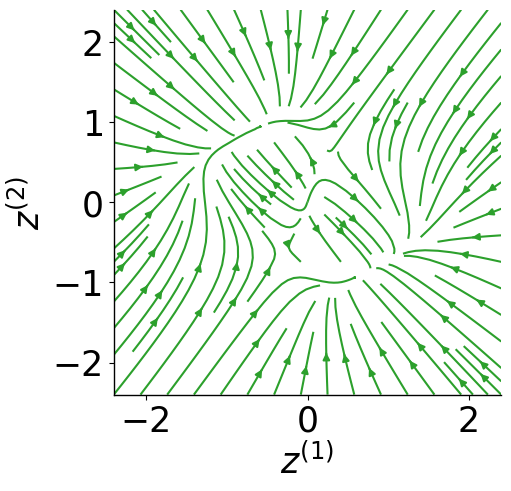

In [ ]:
resolution = 30
x_, y_ = np.meshgrid(
    np.linspace(-2.4, 2.4, num=resolution), 
    np.linspace(-2.4, 2.4, num=resolution)
)

M_hat = np.copy(M_lint_)
N_hat = np.copy(N_lint_)
M_hat[final_labels_lint == 2, :] = 0 # change this to 0, 1, 2, 3 to inhibit different populations

u_ = np.zeros_like(x_)
v_ = np.zeros_like(y_)
u_left_ = np.zeros_like(x_)
v_left_ = np.zeros_like(y_)
u_right_ = np.zeros_like(x_)
v_right_ = np.zeros_like(y_)
energy = np.zeros_like(x_)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for i in range(resolution):
    for j in range(resolution):
        xy = np.array([x_[i, j], y_[i, j]])
        uv_s = -xy + (1/1000) * np.tanh( ( xy @ M_hat.T) ) @ N_hat
        u_[i, j] = uv_s[0]
        v_[i, j] = uv_s[1]

fig, ax = plt.subplots(figsize=(5, 5))

ii = 0
ax.streamplot(x_, y_, u_, v_, color='#2ca02c')

ax.set_xlabel(r'$z^{(1)}$', fontsize=25)
ax.set_ylabel(r'$z^{(2)}$', fontsize=25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.tick_params(axis='both', which='major', labelsize=25)

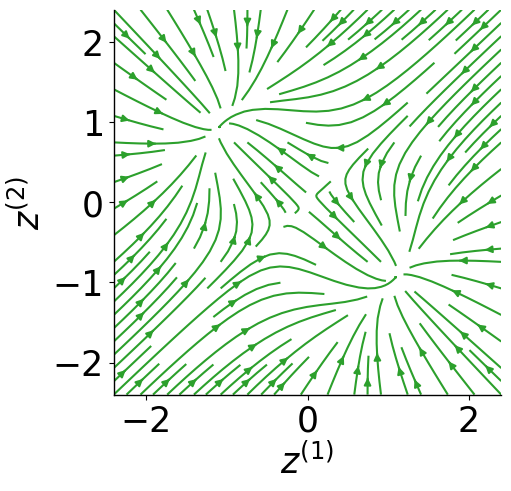

In [ ]:
resolution = 30
x_, y_ = np.meshgrid(
    np.linspace(-2.4, 2.4, num=resolution), 
    np.linspace(-2.4, 2.4, num=resolution)
)

M_hat = np.copy(M_connector)
N_hat = np.copy(N_connector)
M_hat[final_labels_connector == 2,:] = 0 # change this to 0, 1, 2, 3 to inhibit different populations

u_ = np.zeros_like(x_)
v_ = np.zeros_like(y_)
u_left_ = np.zeros_like(x_)
v_left_ = np.zeros_like(y_)
u_right_ = np.zeros_like(x_)
v_right_ = np.zeros_like(y_)
energy = np.zeros_like(x_)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for i in range(resolution):
    for j in range(resolution):
        xy = np.array([x_[i, j], y_[i, j]])
        uv_s = -xy + (1/1000) * np.tanh( ( xy @ M_hat.T) ) @ N_hat
        u_[i, j] = uv_s[0]
        v_[i, j] = uv_s[1]

fig, ax = plt.subplots(figsize=(5, 5))

ii = 0
ax.streamplot(x_, y_, u_, v_, color='#2ca02c')

ax.set_xlabel(r'$z^{(1)}$', fontsize=25)
ax.set_ylabel(r'$z^{(2)}$', fontsize=25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.tick_params(axis='both', which='major', labelsize=25)